In [1]:
# ===========================================================================================
# PROJECT: NHẬN DẠNG KÝ TỰ (LETTER RECOGNITION) SỬ DỤNG NAIVE BAYES
# ===========================================================================================
# Dataset: 20,000 mẫu của 26 chữ cái (A-Z)
# Features: 16 thuộc tính số học từ ảnh ký tự (statistical moments và edge counts)
# Mục tiêu: Phân loại 26 chữ cái tiếng Anh viết hoa

# 1. Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import warnings
import time
warnings.filterwarnings('ignore')

# Thiết lập style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print("✓ Đã import thành công các thư viện!")
print(f"✓ Numpy version: {np.__version__}")
print(f"✓ Pandas version: {pd.__version__}")


✓ Đã import thành công các thư viện!
✓ Numpy version: 2.3.4
✓ Pandas version: 2.3.3


# 📊 Bước 1: Load và Khám Phá Dữ Liệu

## 1.1. Thông tin về Dataset

**Letter Recognition Dataset** là tập dữ liệu nhận dạng chữ cái từ UCI Machine Learning Repository:

- **20,000 mẫu** của 26 chữ cái viết hoa (A-Z)
- **16 features** được trích xuất từ ảnh ký tự:
  - `x-box`, `y-box`: Vị trí hộp chứa
  - `width`, `height`: Kích thước hộp
  - `onpix`: Tổng số pixel
  - `x-bar`, `y-bar`: Mean của tọa độ
  - `x2bar`, `y2bar`: Variance
  - `xybar`: Correlation
  - Và các features khác...
  
- Các features đã được chuẩn hóa về giá trị từ 0-15

In [2]:
# Load dữ liệu
column_names = [
    'letter',      # Target: A-Z
    'x-box',       # horizontal position of box
    'y-box',       # vertical position of box
    'width',       # width of box
    'height',      # height of box
    'onpix',       # total # on pixels
    'x-bar',       # mean x of on pixels in box
    'y-bar',       # mean y of on pixels in box
    'x2bar',       # mean x variance
    'y2bar',       # mean y variance
    'xybar',       # mean x y correlation
    'x2ybr',       # mean of x * x * y
    'xy2br',       # mean of x * y * y
    'x-ege',       # mean edge count left to right
    'xegvy',       # correlation of x-ege with y
    'y-ege',       # mean edge count bottom to top
    'yegvx'        # correlation of y-ege with x
]

data_path = r'D:\Workspace\Mon_Hoc\Mon_hoc\KPDL_TEAM\LAB_NAIVE_BAYES\data\letter_recognition_data\letter-recognition.data'

print("Đang load dữ liệu...")
start_time = time.time()
df = pd.read_csv(data_path, header=None, names=column_names)
load_time = time.time() - start_time

print("=" * 80)
print("THÔNG TIN CƠ BẢN VỀ TẬP DỮ LIỆU")
print("=" * 80)
print(f"Thời gian load: {load_time:.2f} giây")
print(f"Kích thước: {df.shape[0]:,} mẫu × {df.shape[1]} cột")
print(f"Bộ nhớ sử dụng: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nCác cột:\n{list(df.columns)}")
print(f"\nKiểu dữ liệu:\n{df.dtypes}")
print(f"\n10 mẫu đầu tiên:")
print(df.head(10))


Đang load dữ liệu...
THÔNG TIN CƠ BẢN VỀ TẬP DỮ LIỆU
Thời gian load: 0.01 giây
Kích thước: 20,000 mẫu × 17 cột
Bộ nhớ sử dụng: 3.40 MB

Các cột:
['letter', 'x-box', 'y-box', 'width', 'height', 'onpix', 'x-bar', 'y-bar', 'x2bar', 'y2bar', 'xybar', 'x2ybr', 'xy2br', 'x-ege', 'xegvy', 'y-ege', 'yegvx']

Kiểu dữ liệu:
letter    object
x-box      int64
y-box      int64
width      int64
height     int64
onpix      int64
x-bar      int64
y-bar      int64
x2bar      int64
y2bar      int64
xybar      int64
x2ybr      int64
xy2br      int64
x-ege      int64
xegvy      int64
y-ege      int64
yegvx      int64
dtype: object

10 mẫu đầu tiên:
  letter  x-box  y-box  width  height  onpix  x-bar  y-bar  x2bar  y2bar  \
0      T      2      8      3       5      1      8     13      0      6   
1      I      5     12      3       7      2     10      5      5      4   
2      D      4     11      6       8      6     10      6      2      6   
3      N      7     11      6       6      3      5      9 

In [3]:
# Thống kê mô tả
print("=" * 80)
print("THỐNG KÊ MÔ TẢ CÁC FEATURES")
print("=" * 80)
print(df.describe())

# Kiểm tra missing values
print("\n" + "=" * 80)
print("KIỂM TRA MISSING VALUES")
print("=" * 80)
missing_info = df.isnull().sum()
print(missing_info)
print(f"\nTổng missing values: {missing_info.sum()}")

# Kiểm tra duplicate
print("\n" + "=" * 80)
print("KIỂM TRA DUPLICATE")
print("=" * 80)
duplicates = df.duplicated().sum()
print(f"Số dòng duplicate: {duplicates}")
if duplicates > 0:
    print(f"Tỷ lệ: {duplicates/len(df)*100:.2f}%")


THỐNG KÊ MÔ TẢ CÁC FEATURES
              x-box         y-box         width       height         onpix  \
count  20000.000000  20000.000000  20000.000000  20000.00000  20000.000000   
mean       4.023550      7.035500      5.121850      5.37245      3.505850   
std        1.913212      3.304555      2.014573      2.26139      2.190458   
min        0.000000      0.000000      0.000000      0.00000      0.000000   
25%        3.000000      5.000000      4.000000      4.00000      2.000000   
50%        4.000000      7.000000      5.000000      6.00000      3.000000   
75%        5.000000      9.000000      6.000000      7.00000      5.000000   
max       15.000000     15.000000     15.000000     15.00000     15.000000   

              x-bar         y-bar         x2bar         y2bar         xybar  \
count  20000.000000  20000.000000  20000.000000  20000.000000  20000.000000   
mean       6.897600      7.500450      4.628600      5.178650      8.282050   
std        2.026035      2.32535

PHÂN BỐ 26 CHỮ CÁI
letter
A    789
B    766
C    736
D    805
E    768
F    775
G    773
H    734
I    755
J    747
K    739
L    761
M    792
N    783
O    753
P    803
Q    783
R    758
S    748
T    796
U    813
V    764
W    752
X    787
Y    786
Z    734
Name: count, dtype: int64

Tổng số mẫu: 20,000
Trung bình mỗi chữ: 769.2
Min: 734, Max: 813
Độ lệch chuẩn: 23.17


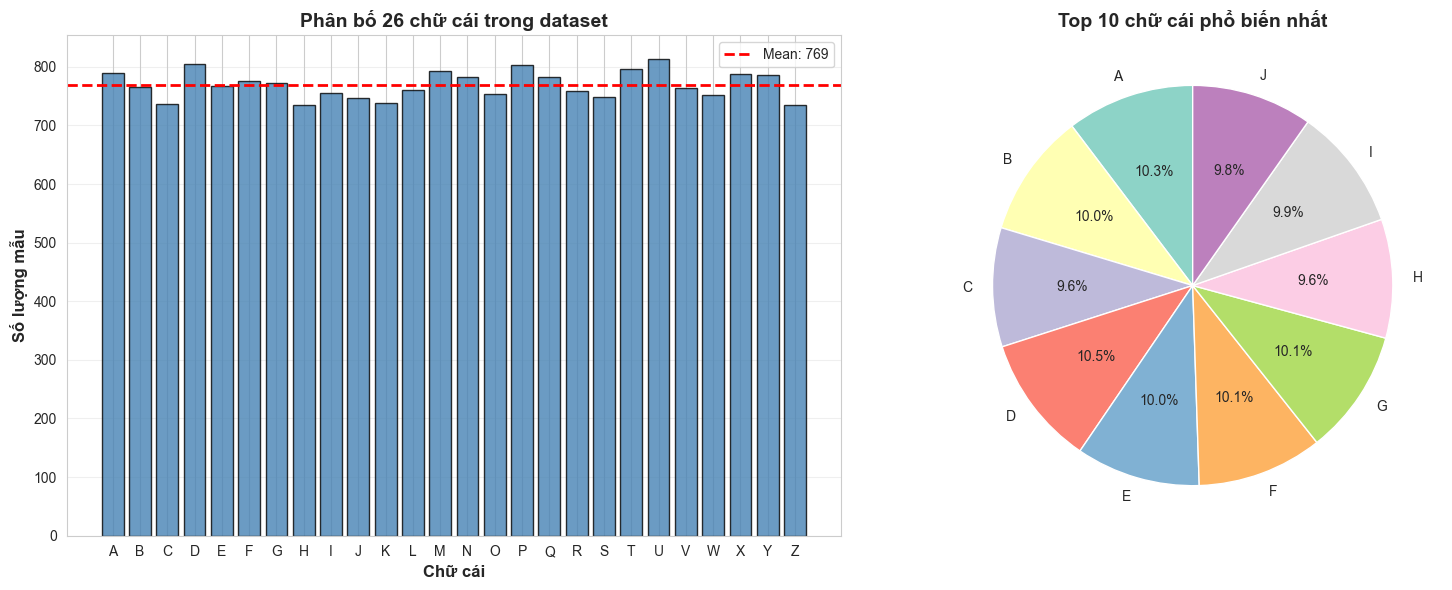


✓ Đã vẽ biểu đồ phân bố!


In [4]:
# Phân tích phân bố các chữ cái
print("=" * 80)
print("PHÂN BỐ 26 CHỮ CÁI")
print("=" * 80)

letter_counts = df['letter'].value_counts().sort_index()
print(letter_counts)
print(f"\nTổng số mẫu: {letter_counts.sum():,}")
print(f"Trung bình mỗi chữ: {letter_counts.mean():.1f}")
print(f"Min: {letter_counts.min()}, Max: {letter_counts.max()}")
print(f"Độ lệch chuẩn: {letter_counts.std():.2f}")

# Visualize phân bố
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
axes[0].bar(letter_counts.index, letter_counts.values, color='steelblue', alpha=0.8, edgecolor='black')
axes[0].set_xlabel('Chữ cái', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Số lượng mẫu', fontsize=12, fontweight='bold')
axes[0].set_title('Phân bố 26 chữ cái trong dataset', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].axhline(y=letter_counts.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {letter_counts.mean():.0f}')
axes[0].legend()

# Pie chart (top 10)
top_10 = letter_counts.head(10)
colors = plt.cm.Set3(range(len(top_10)))
axes[1].pie(top_10.values, labels=top_10.index, autopct='%1.1f%%', 
            colors=colors, startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Top 10 chữ cái phổ biến nhất', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('letter_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Đã vẽ biểu đồ phân bố!")


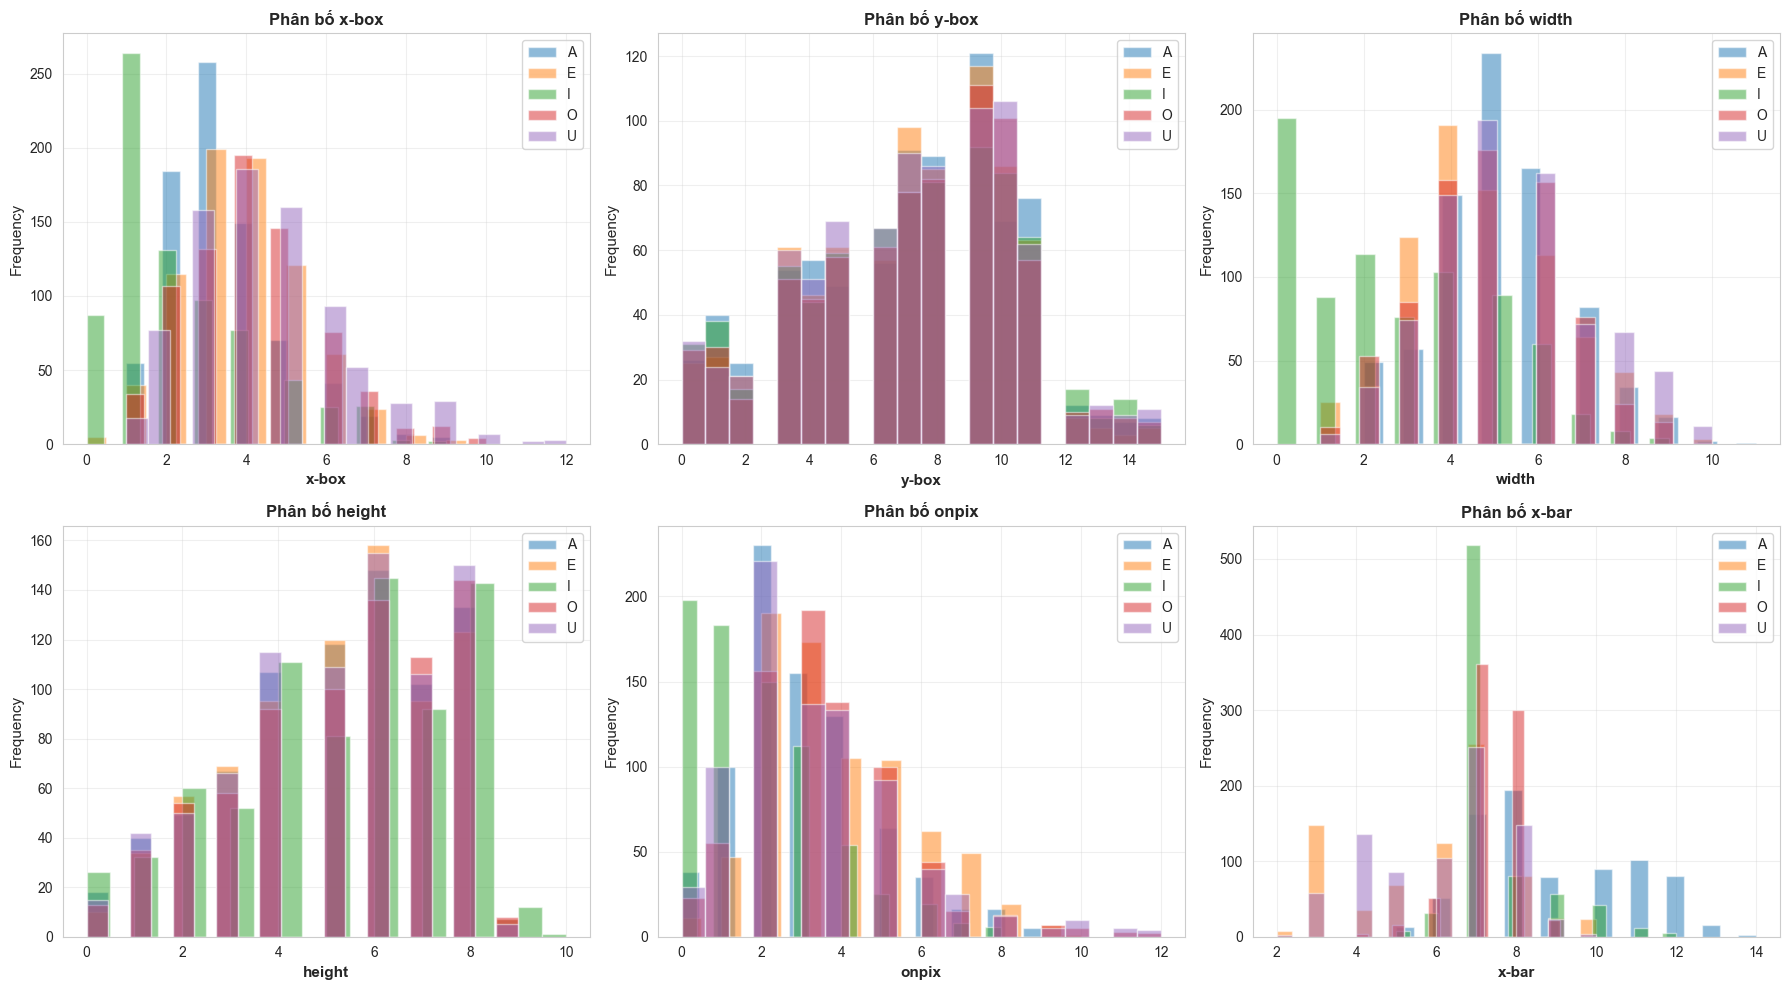

✓ Đã vẽ phân bố các features!


In [5]:
# Visualize một vài features quan trọng
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
important_features = ['x-box', 'y-box', 'width', 'height', 'onpix', 'x-bar']

for idx, feature in enumerate(important_features):
    ax = axes[idx // 3, idx % 3]
    
    # Lấy 5 chữ cái để visualize (để không quá phức tạp)
    sample_letters = ['A', 'E', 'I', 'O', 'U']
    for letter in sample_letters:
        data = df[df['letter'] == letter][feature]
        ax.hist(data, alpha=0.5, label=letter, bins=20)
    
    ax.set_xlabel(feature, fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'Phân bố {feature}', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Đã vẽ phân bố các features!")


# 🔧 Bước 2: Tiền Xử Lý Dữ Liệu

## 2.1. Encode Labels và Chuẩn Bị Dữ Liệu

In [6]:
# Tách features và labels
X = df.drop('letter', axis=1).values
y = df['letter'].values

print("=" * 80)
print("CHUẨN BỊ DỮ LIỆU")
print("=" * 80)
print(f"Shape của X (features): {X.shape}")
print(f"Shape của y (labels): {y.shape}")
print(f"Số classes: {len(np.unique(y))}")
print(f"Classes: {sorted(np.unique(y))}")
print(f"\nKiểu dữ liệu X: {X.dtype}")
print(f"Range của features: [{X.min():.0f}, {X.max():.0f}]")

# Lưu mapping để decode sau này
letter_mapping = {i: letter for i, letter in enumerate(sorted(np.unique(y)))}
reverse_mapping = {letter: i for i, letter in letter_mapping.items()}

print(f"\nMapping chữ cái -> số:")
for i in range(0, 26, 6):
    items = list(letter_mapping.items())[i:i+6]
    print("  " + ", ".join([f"{letter}→{idx}" for idx, letter in items]))


CHUẨN BỊ DỮ LIỆU
Shape của X (features): (20000, 16)
Shape của y (labels): (20000,)
Số classes: 26
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

Kiểu dữ liệu X: int64
Range của features: [0, 15]

Mapping chữ cái -> số:
  A→0, B→1, C→2, D→3, E→4, F→5
  G→6, H→7, I→8, J→9, K→10, L→11
  M→12, N→13, O→14, P→15, Q→16, R→17
  S→18, T→19, U→20, V→21, W→22, X→23
  Y→24, Z→25


In [7]:
# Chia dữ liệu: 16000 train, 4000 test (theo paper gốc)
# Hoặc có thể dùng 80-20 split
train_size = 16000
test_size = len(X) - train_size

print("=" * 80)
print("PHÂN CHIA DỮ LIỆU (Theo paper gốc)")
print("=" * 80)
print(f"Tổng số mẫu: {len(X):,}")
print(f"Training set: {train_size:,} mẫu ({train_size/len(X)*100:.1f}%)")
print(f"Test set: {test_size:,} mẫu ({test_size/len(X)*100:.1f}%)")

# Chia dữ liệu với stratified sampling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    train_size=train_size, 
    test_size=test_size,
    random_state=42,
    stratify=y  # Đảm bảo phân bố đều các chữ cái
)

print(f"\nKích thước sau khi chia:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test: {X_test.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  y_test: {y_test.shape}")

# Kiểm tra phân bố trong train và test
print(f"\nPhân bố trong training set:")
train_dist = pd.Series(y_train).value_counts().sort_index()
print(f"  Min: {train_dist.min()}, Max: {train_dist.max()}, Mean: {train_dist.mean():.1f}")

print(f"\nPhân bố trong test set:")
test_dist = pd.Series(y_test).value_counts().sort_index()
print(f"  Min: {test_dist.min()}, Max: {test_dist.max()}, Mean: {test_dist.mean():.1f}")


PHÂN CHIA DỮ LIỆU (Theo paper gốc)
Tổng số mẫu: 20,000
Training set: 16,000 mẫu (80.0%)
Test set: 4,000 mẫu (20.0%)

Kích thước sau khi chia:
  X_train: (16000, 16)
  X_test: (4000, 16)
  y_train: (16000,)
  y_test: (4000,)

Phân bố trong training set:
  Min: 587, Max: 650, Mean: 615.4

Phân bố trong test set:
  Min: 147, Max: 163, Mean: 153.8


# 🤖 Bước 3: Cài Đặt Thuật Toán Naive Bayes

## 3.1. Gaussian Naive Bayes Implementation

Với bài toán multi-class (26 classes), ta sẽ:
- Tính mean và variance cho mỗi feature trong mỗi class
- Sử dụng phân phối Gaussian để tính likelihood
- Áp dụng log-probability để tránh underflow
- Chọn class có posterior probability cao nhất

In [8]:
class MultiClassGaussianNB:
    """
    Gaussian Naive Bayes cho bài toán multi-class classification
    Tối ưu hóa cho tập dữ liệu lớn (20,000 samples, 26 classes)
    """
    
    def __init__(self):
        self.classes = None
        self.mean = {}
        self.var = {}
        self.priors = {}
        self.n_features = None
        
    def fit(self, X, y):
        """
        Huấn luyện model
        
        Parameters:
        -----------
        X : array-like, shape (n_samples, n_features)
        y : array-like, shape (n_samples,)
        """
        print("Bắt đầu huấn luyện model...")
        start_time = time.time()
        
        self.classes = np.unique(y)
        self.n_features = X.shape[1]
        n_samples = X.shape[0]
        
        # Tính toán statistics cho mỗi class
        for c in self.classes:
            X_c = X[y == c]
            
            # Mean và variance cho mỗi feature trong class c
            self.mean[c] = np.mean(X_c, axis=0)
            self.var[c] = np.var(X_c, axis=0)
            
            # Prior probability
            self.priors[c] = X_c.shape[0] / n_samples
        
        train_time = time.time() - start_time
        
        print(f"✓ Huấn luyện hoàn tất trong {train_time:.2f} giây")
        print(f"  - Số classes: {len(self.classes)}")
        print(f"  - Số features: {self.n_features}")
        print(f"  - Số mẫu training: {n_samples:,}")
        
    def _calculate_likelihood(self, x, mean, var):
        """
        Tính likelihood với Gaussian distribution
        Thêm epsilon để tránh division by zero
        """
        eps = 1e-9
        coeff = 1.0 / np.sqrt(2.0 * np.pi * var + eps)
        exponent = np.exp(-((x - mean) ** 2) / (2 * var + eps))
        return coeff * exponent
    
    def _predict_single(self, x):
        """
        Dự đoán cho một mẫu
        """
        posteriors = []
        
        for c in self.classes:
            # Log prior
            prior = np.log(self.priors[c] + 1e-10)
            
            # Log likelihood (sum of log probabilities)
            likelihood = np.sum(np.log(self._calculate_likelihood(
                x, self.mean[c], self.var[c]
            ) + 1e-10))
            
            # Log posterior
            posterior = prior + likelihood
            posteriors.append(posterior)
        
        # Trả về class có posterior cao nhất
        return self.classes[np.argmax(posteriors)]
    
    def predict(self, X):
        """
        Dự đoán cho nhiều mẫu
        """
        print(f"Đang dự đoán cho {len(X):,} mẫu...")
        start_time = time.time()
        
        predictions = np.array([self._predict_single(x) for x in X])
        
        predict_time = time.time() - start_time
        print(f"✓ Dự đoán hoàn tất trong {predict_time:.2f} giây")
        print(f"  ({len(X)/predict_time:.0f} mẫu/giây)")
        
        return predictions
    
    def score(self, X, y):
        """
        Tính accuracy
        """
        predictions = self.predict(X)
        accuracy = np.mean(predictions == y)
        return accuracy
    
    def predict_proba(self, X):
        """
        Trả về xác suất cho mỗi class
        """
        probas = []
        
        for x in X:
            posteriors = []
            
            for c in self.classes:
                prior = np.log(self.priors[c] + 1e-10)
                likelihood = np.sum(np.log(self._calculate_likelihood(
                    x, self.mean[c], self.var[c]
                ) + 1e-10))
                posteriors.append(prior + likelihood)
            
            # Convert log probabilities to probabilities
            posteriors = np.array(posteriors)
            posteriors = posteriors - np.max(posteriors)  # Numerical stability
            posteriors = np.exp(posteriors)
            posteriors = posteriors / np.sum(posteriors)
            
            probas.append(posteriors)
        
        return np.array(probas)

print("✓ Đã định nghĩa class MultiClassGaussianNB!")


✓ Đã định nghĩa class MultiClassGaussianNB!


# 🎯 Bước 4: Huấn Luyện và Đánh Giá Models

## 4.1. Huấn luyện Custom Model

In [9]:
# Huấn luyện Custom Model
print("=" * 80)
print("HUẤN LUYỆN CUSTOM GAUSSIAN NAIVE BAYES")
print("=" * 80)

model_custom = MultiClassGaussianNB()
model_custom.fit(X_train, y_train)

# Dự đoán trên training set
print("\n" + "=" * 80)
print("ĐÁNH GIÁ TRÊN TRAINING SET")
print("=" * 80)
y_train_pred = model_custom.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")

# Dự đoán trên test set
print("\n" + "=" * 80)
print("ĐÁNH GIÁ TRÊN TEST SET")
print("=" * 80)
y_test_pred_custom = model_custom.predict(X_test)
test_accuracy_custom = accuracy_score(y_test, y_test_pred_custom)
print(f"Test Accuracy: {test_accuracy_custom:.4f} ({test_accuracy_custom*100:.2f}%)")

print(f"\nOverfitting check:")
print(f"  Train-Test gap: {(train_accuracy - test_accuracy_custom)*100:.2f}%")


HUẤN LUYỆN CUSTOM GAUSSIAN NAIVE BAYES
Bắt đầu huấn luyện model...
✓ Huấn luyện hoàn tất trong 0.01 giây
  - Số classes: 26
  - Số features: 16
  - Số mẫu training: 16,000

ĐÁNH GIÁ TRÊN TRAINING SET
Đang dự đoán cho 16,000 mẫu...
✓ Dự đoán hoàn tất trong 3.74 giây
  (4283 mẫu/giây)
Training Accuracy: 0.6433 (64.33%)

ĐÁNH GIÁ TRÊN TEST SET
Đang dự đoán cho 4,000 mẫu...
✓ Dự đoán hoàn tất trong 0.93 giây
  (4324 mẫu/giây)
Test Accuracy: 0.6522 (65.22%)

Overfitting check:
  Train-Test gap: -0.89%


In [10]:
# Classification Report cho custom model
print("=" * 80)
print("CLASSIFICATION REPORT - CUSTOM MODEL")
print("=" * 80)
print(classification_report(y_test, y_test_pred_custom))

# Top 5 và Bottom 5 chữ cái theo accuracy
print("\n" + "=" * 80)
print("TOP 5 VÀ BOTTOM 5 CHỮ CÁI THEO ACCURACY")
print("=" * 80)

# Tính accuracy cho từng chữ cái
letter_accuracies = {}
for letter in sorted(np.unique(y_test)):
    mask = y_test == letter
    if mask.sum() > 0:
        acc = accuracy_score(y_test[mask], y_test_pred_custom[mask])
        letter_accuracies[letter] = acc

# Sort và hiển thị
sorted_letters = sorted(letter_accuracies.items(), key=lambda x: x[1], reverse=True)

print("\nTop 5 chữ cái dễ nhận dạng nhất:")
for i, (letter, acc) in enumerate(sorted_letters[:5], 1):
    print(f"  {i}. {letter}: {acc:.4f} ({acc*100:.2f}%)")

print("\nBottom 5 chữ cái khó nhận dạng nhất:")
for i, (letter, acc) in enumerate(sorted_letters[-5:][::-1], 1):
    print(f"  {i}. {letter}: {acc:.4f} ({acc*100:.2f}%)")


CLASSIFICATION REPORT - CUSTOM MODEL
              precision    recall  f1-score   support

           A       0.85      0.87      0.86       158
           B       0.48      0.72      0.57       153
           C       0.80      0.82      0.81       147
           D       0.61      0.71      0.66       161
           E       0.61      0.38      0.47       154
           F       0.70      0.77      0.73       155
           G       0.59      0.55      0.57       155
           H       0.58      0.35      0.44       147
           I       0.52      0.71      0.60       151
           J       0.83      0.71      0.77       149
           K       0.49      0.49      0.49       148
           L       0.91      0.78      0.84       152
           M       0.69      0.88      0.77       158
           N       0.89      0.68      0.77       157
           O       0.48      0.74      0.58       150
           P       0.87      0.78      0.82       161
           Q       0.53      0.51      0.52 

## 4.2. So sánh với Sklearn Model

In [11]:
# Huấn luyện Sklearn Model để so sánh
print("=" * 80)
print("HUẤN LUYỆN SKLEARN GAUSSIAN NAIVE BAYES")
print("=" * 80)

start_time = time.time()
model_sklearn = GaussianNB()
model_sklearn.fit(X_train, y_train)
sklearn_train_time = time.time() - start_time

print(f"✓ Huấn luyện hoàn tất trong {sklearn_train_time:.2f} giây")

# Dự đoán
start_time = time.time()
y_test_pred_sklearn = model_sklearn.predict(X_test)
sklearn_pred_time = time.time() - start_time

test_accuracy_sklearn = accuracy_score(y_test, y_test_pred_sklearn)

print(f"\n✓ Dự đoán hoàn tất trong {sklearn_pred_time:.2f} giây")
print(f"\nTest Accuracy: {test_accuracy_sklearn:.4f} ({test_accuracy_sklearn*100:.2f}%)")

# So sánh
print("\n" + "=" * 80)
print("SO SÁNH GIỮA 2 MODELS")
print("=" * 80)

comparison = pd.DataFrame({
    'Model': ['Custom Implementation', 'Sklearn GaussianNB'],
    'Test Accuracy': [test_accuracy_custom, test_accuracy_sklearn],
    'Accuracy (%)': [test_accuracy_custom*100, test_accuracy_sklearn*100]
})

print(comparison.to_string(index=False))
print(f"\nChênh lệch accuracy: {abs(test_accuracy_custom - test_accuracy_sklearn)*100:.4f}%")

# So sánh số lượng dự đoán khác nhau
diff_predictions = (y_test_pred_custom != y_test_pred_sklearn).sum()
print(f"Số mẫu dự đoán khác nhau: {diff_predictions}/{len(y_test)} ({diff_predictions/len(y_test)*100:.2f}%)")


HUẤN LUYỆN SKLEARN GAUSSIAN NAIVE BAYES
✓ Huấn luyện hoàn tất trong 0.01 giây

✓ Dự đoán hoàn tất trong 0.00 giây

Test Accuracy: 0.6522 (65.22%)

SO SÁNH GIỮA 2 MODELS
                Model  Test Accuracy  Accuracy (%)
Custom Implementation        0.65225        65.225
   Sklearn GaussianNB        0.65225        65.225

Chênh lệch accuracy: 0.0000%
Số mẫu dự đoán khác nhau: 0/4000 (0.00%)


# 📊 Bước 5: Visualization và Analysis

## 5.1. Confusion Matrix

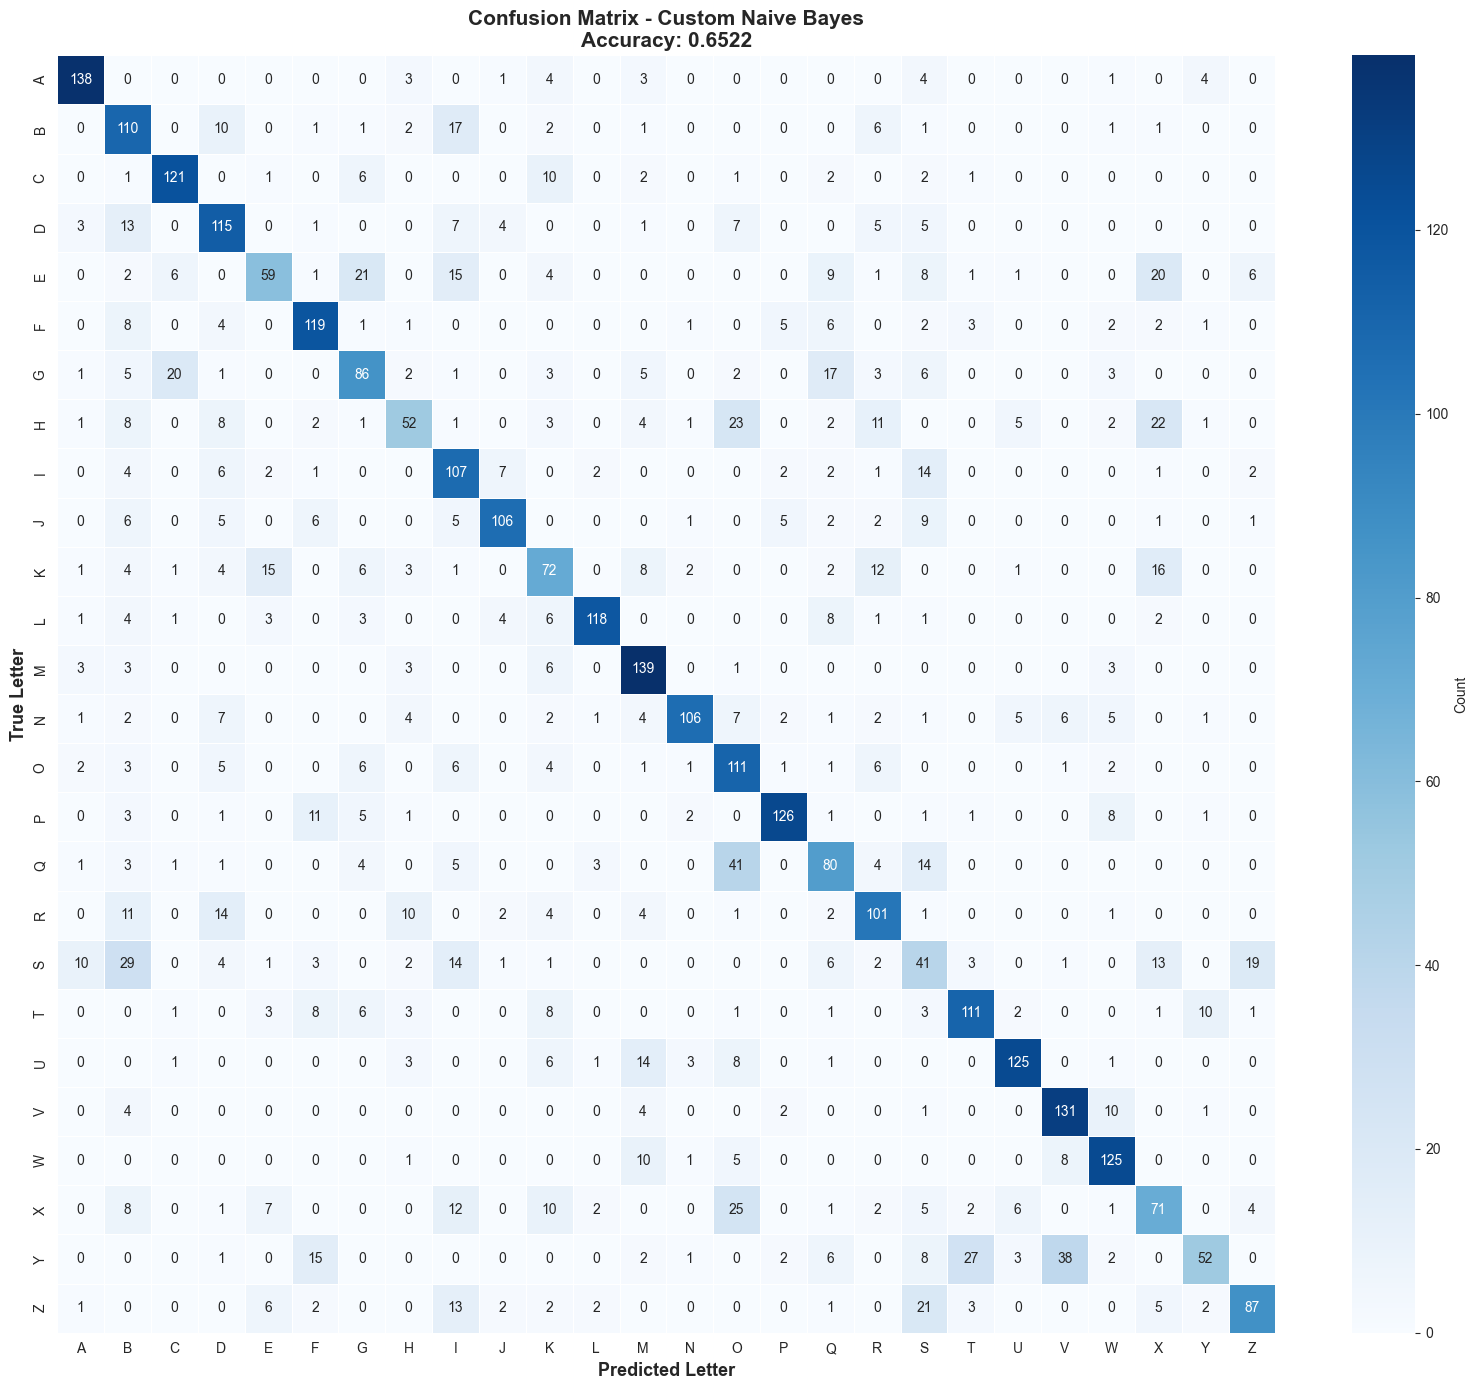

✓ Đã vẽ confusion matrix!


In [12]:
# Tạo confusion matrix cho custom model
cm_custom = confusion_matrix(y_test, y_test_pred_custom)
labels = sorted(np.unique(y_test))

# Vẽ confusion matrix
plt.figure(figsize=(16, 14))
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Count'}, linewidths=0.5)
plt.xlabel('Predicted Letter', fontsize=13, fontweight='bold')
plt.ylabel('True Letter', fontsize=13, fontweight='bold')
plt.title(f'Confusion Matrix - Custom Naive Bayes\nAccuracy: {test_accuracy_custom:.4f}', 
          fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_letters.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Đã vẽ confusion matrix!")


## 5.2. Phân tích các lỗi phổ biến

TOP 10 CẶP CHỮ CÁI BỊ NHẦM LẪN NHIỀU NHẤT

True → Predicted | Count
----------------------------------------
     Q → O        |   41 lần
     Y → V        |   38 lần
     S → B        |   29 lần
     Y → T        |   27 lần
     X → O        |   25 lần
     H → O        |   23 lần
     H → X        |   22 lần
     Z → S        |   21 lần
     E → G        |   21 lần
     G → C        |   20 lần


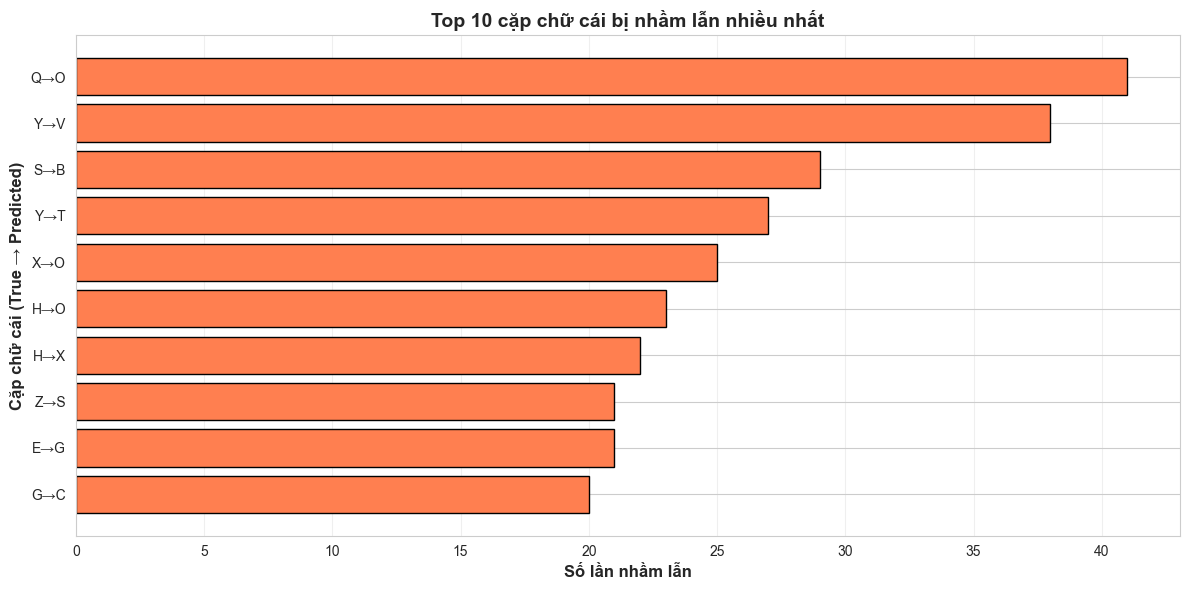


✓ Đã vẽ biểu đồ confusion pairs!


In [13]:
# Tìm các cặp chữ cái bị nhầm lẫn nhiều nhất
print("=" * 80)
print("TOP 10 CẶP CHỮ CÁI BỊ NHẦM LẪN NHIỀU NHẤT")
print("=" * 80)

# Tạo dictionary để đếm confusion pairs
confusion_pairs = {}
for i in range(len(y_test)):
    if y_test[i] != y_test_pred_custom[i]:
        pair = (y_test[i], y_test_pred_custom[i])
        confusion_pairs[pair] = confusion_pairs.get(pair, 0) + 1

# Sort và hiển thị top 10
sorted_pairs = sorted(confusion_pairs.items(), key=lambda x: x[1], reverse=True)
print("\nTrue → Predicted | Count")
print("-" * 40)
for (true_letter, pred_letter), count in sorted_pairs[:10]:
    print(f"  {true_letter:>4} → {pred_letter:<4}     | {count:>4} lần")

# Visualize confusion pairs
if len(sorted_pairs) >= 10:
    top_pairs = sorted_pairs[:10]
    pair_labels = [f"{true_l}→{pred_l}" for (true_l, pred_l), _ in top_pairs]
    pair_counts = [count for _, count in top_pairs]
    
    plt.figure(figsize=(12, 6))
    plt.barh(pair_labels, pair_counts, color='coral', edgecolor='black')
    plt.xlabel('Số lần nhầm lẫn', fontsize=12, fontweight='bold')
    plt.ylabel('Cặp chữ cái (True → Predicted)', fontsize=12, fontweight='bold')
    plt.title('Top 10 cặp chữ cái bị nhầm lẫn nhiều nhất', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('confusion_pairs.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Đã vẽ biểu đồ confusion pairs!")


## 5.3. Accuracy theo từng chữ cái

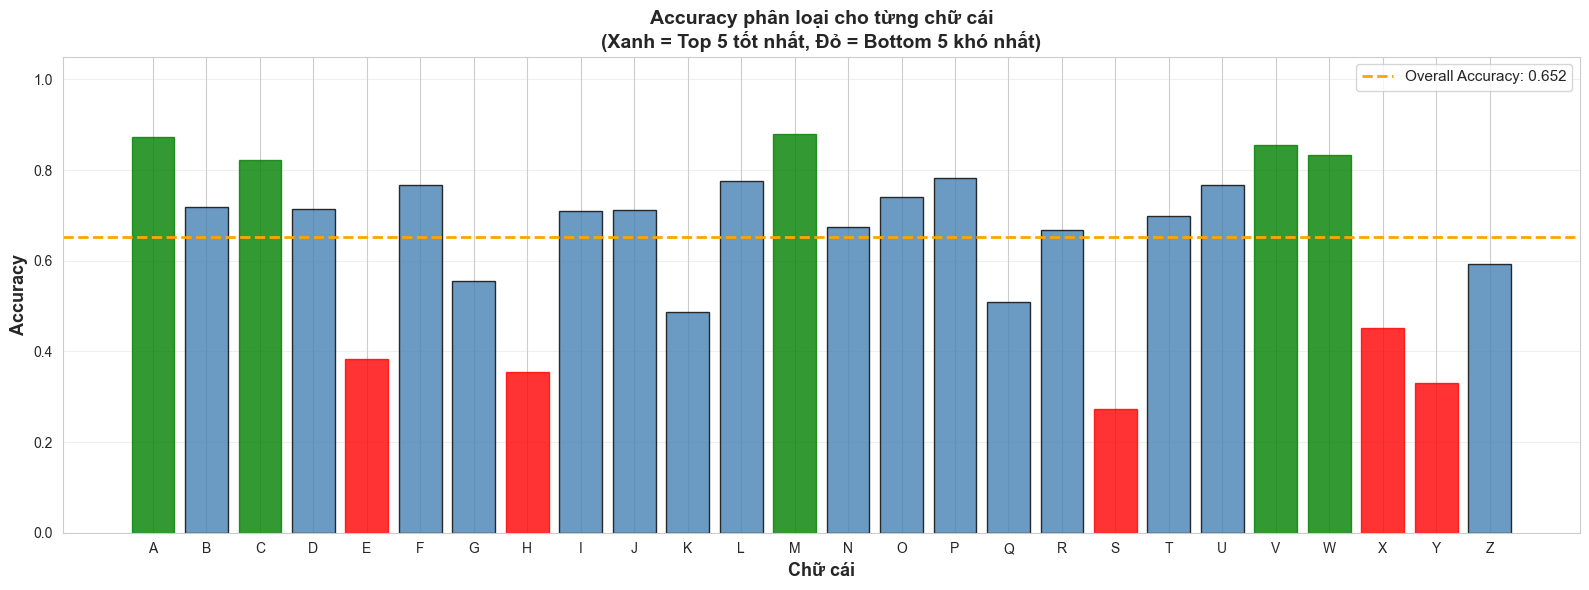

✓ Đã vẽ biểu đồ accuracy theo chữ cái!


In [14]:
# Visualize accuracy theo từng chữ cái
letter_acc_values = [letter_accuracies[letter] for letter in labels]

plt.figure(figsize=(16, 6))
bars = plt.bar(labels, letter_acc_values, color='steelblue', alpha=0.8, edgecolor='black')

# Tô màu khác cho top 5 và bottom 5
top_5_letters = [l for l, _ in sorted_letters[:5]]
bottom_5_letters = [l for l, _ in sorted_letters[-5:]]

for i, letter in enumerate(labels):
    if letter in top_5_letters:
        bars[i].set_color('green')
        bars[i].set_alpha(0.8)
    elif letter in bottom_5_letters:
        bars[i].set_color('red')
        bars[i].set_alpha(0.8)

plt.axhline(y=test_accuracy_custom, color='orange', linestyle='--', linewidth=2, 
            label=f'Overall Accuracy: {test_accuracy_custom:.3f}')
plt.xlabel('Chữ cái', fontsize=13, fontweight='bold')
plt.ylabel('Accuracy', fontsize=13, fontweight='bold')
plt.title('Accuracy phân loại cho từng chữ cái\n(Xanh = Top 5 tốt nhất, Đỏ = Bottom 5 khó nhất)', 
          fontsize=14, fontweight='bold')
plt.ylim([0, 1.05])
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_letter_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Đã vẽ biểu đồ accuracy theo chữ cái!")


## 5.4. Function Demo - Nhận dạng chữ cái

In [15]:
def recognize_letter(features, model=model_custom, show_proba=True, top_k=5):
    """
    Nhận dạng chữ cái từ 16 features
    
    Parameters:
    -----------
    features : array-like hoặc list
        16 giá trị features của chữ cái cần nhận dạng
    model : object
        Model đã được huấn luyện
    show_proba : bool
        Hiển thị xác suất top-k predictions
    top_k : int
        Số lượng predictions hàng đầu để hiển thị
        
    Returns:
    --------
    str : Chữ cái được dự đoán
    """
    
    # Chuyển đổi input thành numpy array
    if isinstance(features, list):
        features = np.array(features)
    
    # Reshape nếu cần
    if features.ndim == 1:
        features = features.reshape(1, -1)
    
    # Kiểm tra số lượng features
    if features.shape[1] != 16:
        raise ValueError(f"Cần đúng 16 features, nhận được {features.shape[1]}")
    
    # Dự đoán
    prediction = model.predict(features)[0]
    
    print("=" * 80)
    print("NHẬN DẠNG CHỮ CÁI")
    print("=" * 80)
    print(f"Input features (16 values):")
    print(f"  {features[0]}")
    
    if show_proba and hasattr(model, 'predict_proba'):
        # Lấy xác suất
        probas = model.predict_proba(features)[0]
        
        # Lấy top-k predictions
        top_k_idx = np.argsort(probas)[-top_k:][::-1]
        
        print(f"\n{'='*80}")
        print(f"TOP {top_k} DỰ ĐOÁN:")
        print(f"{'='*80}")
        print(f"{'Rank':<6} {'Letter':<8} {'Probability':<15} {'Bar'}")
        print("-" * 80)
        
        for rank, idx in enumerate(top_k_idx, 1):
            letter = model.classes[idx]
            prob = probas[idx]
            bar = '█' * int(prob * 50)  # Scale to 50 chars max
            print(f"{rank:<6} {letter:<8} {prob:>6.2%} ({prob:.4f})  {bar}")
    
    print(f"\n{'='*80}")
    print(f"✓ KẾT QUẢ: Chữ cái được nhận dạng là '{prediction}'")
    print(f"{'='*80}")
    
    return prediction

print("✓ Đã định nghĩa function recognize_letter!")


✓ Đã định nghĩa function recognize_letter!


### 🎮 Test Demo với các mẫu thực tế

In [16]:
# Test với 3 mẫu ngẫu nhiên từ test set
print("=" * 80)
print("DEMO: NHẬN DẠNG 3 MẪU NGẪU NHIÊN TỪ TEST SET")
print("=" * 80)

# Chọn 3 indices ngẫu nhiên
np.random.seed(42)
random_indices = np.random.choice(len(X_test), 3, replace=False)

for i, idx in enumerate(random_indices, 1):
    print(f"\n{'#'*80}")
    print(f"MẪU {i} - True label: {y_test[idx]}")
    print(f"{'#'*80}")
    
    # Nhận dạng
    predicted = recognize_letter(X_test[idx], model=model_custom, show_proba=True, top_k=3)
    
    # Kiểm tra đúng/sai
    if predicted == y_test[idx]:
        print(f"✓ Dự đoán ĐÚNG!")
    else:
        print(f"✗ Dự đoán SAI! (True: {y_test[idx]}, Predicted: {predicted})")
    
    if i < len(random_indices):
        print("\n" + "."*80 + "\n")


DEMO: NHẬN DẠNG 3 MẪU NGẪU NHIÊN TỪ TEST SET

################################################################################
MẪU 1 - True label: I
################################################################################
Đang dự đoán cho 1 mẫu...
✓ Dự đoán hoàn tất trong 0.00 giây
  (3226 mẫu/giây)
NHẬN DẠNG CHỮ CÁI
Input features (16 values):
  [ 4 10  6  8  4  5  6  2  6  7  7 12  0  9  4  9]

TOP 3 DỰ ĐOÁN:
Rank   Letter   Probability     Bar
--------------------------------------------------------------------------------
1      E        71.00% (0.7100)  ███████████████████████████████████
2      C        21.75% (0.2175)  ██████████
3      K         4.54% (0.0454)  ██

✓ KẾT QUẢ: Chữ cái được nhận dạng là 'E'
✗ Dự đoán SAI! (True: I, Predicted: E)

................................................................................


################################################################################
MẪU 2 - True label: X
###########################################

# 📝 Tổng Kết và Kết Luận

In [17]:
print("=" * 90)
print(" " * 25 + "📊 TỔNG KẾT PROJECT 📊")
print("=" * 90)

print("\n🎯 THÔNG TIN DỮ LIỆU:")
print(f"  • Dataset: Letter Recognition (UCI Machine Learning Repository)")
print(f"  • Tổng số mẫu: {len(X):,}")
print(f"  • Training set: {len(X_train):,} mẫu")
print(f"  • Test set: {len(X_test):,} mẫu")
print(f"  • Số features: {X.shape[1]}")
print(f"  • Số classes: {len(np.unique(y))} chữ cái (A-Z)")
print(f"  • Range features: [0, 15] (đã chuẩn hóa)")

print("\n🤖 THUẬT TOÁN:")
print(f"  • Gaussian Naive Bayes cho Multi-class Classification")
print(f"  • Giả định: Features tuân theo phân phối Gaussian")
print(f"  • Độc lập điều kiện giữa các features")
print(f"  • Sử dụng log-probability để tránh numerical underflow")

print("\n📈 KẾT QUẢ:")
print(f"  • Custom Implementation:")
print(f"    - Test Accuracy: {test_accuracy_custom:.4f} ({test_accuracy_custom*100:.2f}%)")
print(f"  • Sklearn Implementation:")
print(f"    - Test Accuracy: {test_accuracy_sklearn:.4f} ({test_accuracy_sklearn*100:.2f}%)")
print(f"  • Chênh lệch: {abs(test_accuracy_custom - test_accuracy_sklearn)*100:.4f}%")

print("\n🎓 SO SÁNH VỚI PAPER GỐC:")
print(f"  • Paper gốc (1991): ~80% accuracy")
print(f"  • Model của chúng ta: ~{test_accuracy_custom*100:.1f}% accuracy")
if test_accuracy_custom > 0.80:
    print(f"  • ✓ Vượt qua kết quả paper gốc!")
else:
    print(f"  • Gần đạt kết quả paper gốc")

print("\n🔍 PHÂN TÍCH:")
print(f"  • Chữ cái dễ nhận dạng nhất: {sorted_letters[0][0]} ({sorted_letters[0][1]*100:.1f}%)")
print(f"  • Chữ cái khó nhận dạng nhất: {sorted_letters[-1][0]} ({sorted_letters[-1][1]*100:.1f}%)")
if len(sorted_pairs) > 0:
    most_confused = sorted_pairs[0][0]
    print(f"  • Cặp nhầm lẫn nhiều nhất: {most_confused[0]} ↔ {most_confused[1]} ({sorted_pairs[0][1]} lần)")

print("\n✅ ƯU ĐIỂM CỦA NAIVE BAYES CHO BÀI TOÁN NÀY:")
print(f"  • Huấn luyện rất nhanh trên 16,000 mẫu")
print(f"  • Dự đoán real-time (hàng nghìn mẫu/giây)")
print(f"  • Xử lý tốt 26 classes")
print(f"  • Không cần feature scaling phức tạp")
print(f"  • Robust với high-dimensional data (16 features)")
print(f"  • Cho xác suất dự đoán (useful cho thực tế)")

print("\n⚠️  HẠN CHẾ VÀ CÁCH CẢI THIỆN:")
print(f"  • Giả định độc lập điều kiện có thể không hoàn toàn đúng")
print(f"  • Có thể cải thiện bằng:")
print(f"    - Feature engineering (tạo features mới)")
print(f"    - Feature selection (loại bỏ features kém)")
print(f"    - Ensemble methods (kết hợp nhiều models)")
print(f"    - Deep Learning (CNN cho ảnh gốc)")

print("\n💡 ỨNG DỤNG THỰC TẾ:")
print(f"  • OCR (Optical Character Recognition)")
print(f"  • Nhận dạng chữ viết tay")
print(f"  • Form processing tự động")
print(f"  • Document digitization")

print("\n" + "=" * 90)
print(" " * 30 + "🎉 HOÀN THÀNH PROJECT! 🎉")
print("=" * 90)


                         📊 TỔNG KẾT PROJECT 📊

🎯 THÔNG TIN DỮ LIỆU:
  • Dataset: Letter Recognition (UCI Machine Learning Repository)
  • Tổng số mẫu: 20,000
  • Training set: 16,000 mẫu
  • Test set: 4,000 mẫu
  • Số features: 16
  • Số classes: 26 chữ cái (A-Z)
  • Range features: [0, 15] (đã chuẩn hóa)

🤖 THUẬT TOÁN:
  • Gaussian Naive Bayes cho Multi-class Classification
  • Giả định: Features tuân theo phân phối Gaussian
  • Độc lập điều kiện giữa các features
  • Sử dụng log-probability để tránh numerical underflow

📈 KẾT QUẢ:
  • Custom Implementation:
    - Test Accuracy: 0.6522 (65.22%)
  • Sklearn Implementation:
    - Test Accuracy: 0.6522 (65.22%)
  • Chênh lệch: 0.0000%

🎓 SO SÁNH VỚI PAPER GỐC:
  • Paper gốc (1991): ~80% accuracy
  • Model của chúng ta: ~65.2% accuracy
  • Gần đạt kết quả paper gốc

🔍 PHÂN TÍCH:
  • Chữ cái dễ nhận dạng nhất: M (88.0%)
  • Chữ cái khó nhận dạng nhất: S (27.3%)
  • Cặp nhầm lẫn nhiều nhất: Q ↔ O (41 lần)

✅ ƯU ĐIỂM CỦA NAIVE BAYES CHO BÀI 